In [4]:
import os
os.listdir()



['Untitled.ipynb',
 'artist_data.csv',
 'sqlite.ipynb',
 'r.ipynb',
 'Intro.ipynb',
 'cpp-smallpt.ipynb',
 'cpp-third-party-libs.ipynb',
 'cpp.ipynb',
 'Lorenz.ipynb']

In [39]:
import pandas as pd
import numpy as np

In [7]:
#import data
df = pd.read_csv("artist_data.csv")
df.head()

,id,name,artist_popularity,artist_genres,followers,genre_0,genre_1,genre_2,genre_3,genre_4,genre_5,genre_6
0,6pE6WjaGLjkatxCY7ie3x3,Red Hot Blues,4,['blues band'],170,blues band,NaN,NaN,NaN,NaN,NaN,NaN
1,1pFgLnwVfIZh0Qztd0LYqY,Gentle Hen,4,['western mass indie'],378,western mass indie,NaN,NaN,NaN,NaN,NaN,NaN
2,27kz8ieduFE45c5rdyHcxj,Colin Grant,5,['canadian celtic'],540,canadian celtic,NaN,NaN,NaN,NaN,NaN,NaN
3,75AqhRq4n2mgow58AcHe5m,DAYNE OTB,5,['oc rap'],562,oc rap,NaN,NaN,NaN,NaN,NaN,NaN
4,2Acjtki9xGNwsweZVFx6Ed,Turned Around,5,['future bounce'],557,future bounce,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
#inspect the dataset
len(df.columns)
print(f"1. Number of columns: {len(df.columns)}")

print("2. Column types:")
for col in df.columns:
    print (f"{col}: {df[col].dtypes}")

1. Number of columns: 12
2. Column types:
id: str
name: str
artist_popularity: int64
artist_genres: str
followers: int64
genre_0: str
genre_1: str
genre_2: str
genre_3: str
genre_4: str
genre_5: float64
genre_6: float64


In [21]:
#unique artists
num_artists = df["name"].nunique()

print("3. Number of unique artists:", num_artists)

3. Number of unique artists: 15314


In [25]:
top_popularity = df.sort_values(by="artist_popularity", ascending=False).head(10)

print("4. Top 10 artists by popularity")
top_popularity[["name", "artist_popularity"]]

4. Top 10 artists by popularity


,name,artist_popularity
15528,Taylor Swift,100
15527,Drake,95
15526,Bad Bunny,95
15525,The Weeknd,93
15524,Peso Pluma,90
15523,Kanye West,90
15522,Travis Scott,90
15519,Jung Kook,89
15520,Lana Del Rey,89
15521,Eminem,89


In [26]:
top_followers = df.sort_values(by="followers", ascending=False).head(10)

print("5. Top 10 artists by number of followers")
top_followers[["name", "followers"]]

5. Top 10 artists by number of followers


,name,followers
15511,Ed Sheeran,115998928
15528,Taylor Swift,95859165
15512,Ariana Grande,95710972
15510,Billie Eilish,89996504
15527,Drake,83298497
15521,Eminem,79891173
15526,Bad Bunny,77931484
15525,The Weeknd,75945958
15514,Justin Bieber,75112165
15491,BTS,71720409


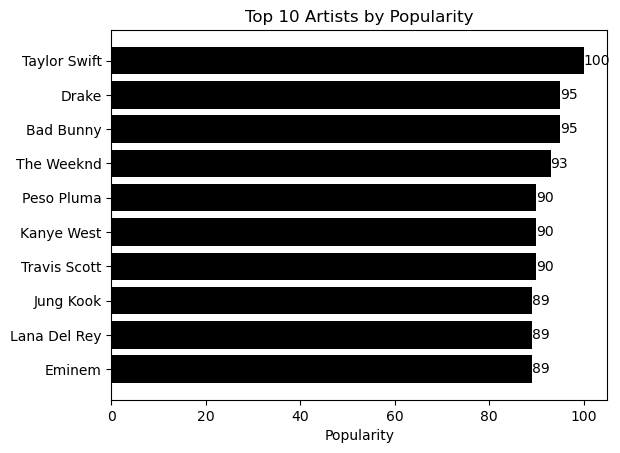

In [30]:
plt.figure()
plt.barh(top_popularity["name"], 
         top_popularity["artist_popularity"],
        color="black")
# add count at the end of the bar
for i, value in enumerate(top_popularity["artist_popularity"]):
    plt.text(value, i, f"{value:.0f}", va='center')
plt.xlabel("Popularity")
plt.title("Top 10 Artists by Popularity")
plt.gca().invert_yaxis()
plt.show()

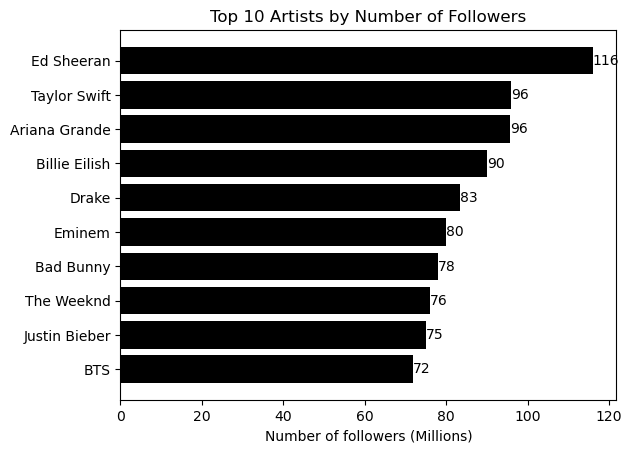

In [34]:
plt.figure()
# change to millions
followers_millions = top_followers["followers"] / 1_000_000

plt.barh(top_followers["name"], 
         followers_millions,
        color="black")

# add count at the end of the bar
for i, value in enumerate(followers_millions):
    plt.text(value, i, f"{value:.0f}", va='center')
plt.xlabel("Number of followers (Millions)")
plt.title("Top 10 Artists by Number of Followers")
plt.gca().invert_yaxis()
plt.show()

In [36]:
#Popularity vs followers.
correlation = df["artist_popularity"].corr(df["followers"])
print(f"Correlation: {correlation}")


Correlation: 0.35347311139476273



6. Pearson correlation(popularity, followers) = 0.3535

7. OLS regression (no statsmodels):
Popularity = -14.234 + 5.085 * log(Followers)


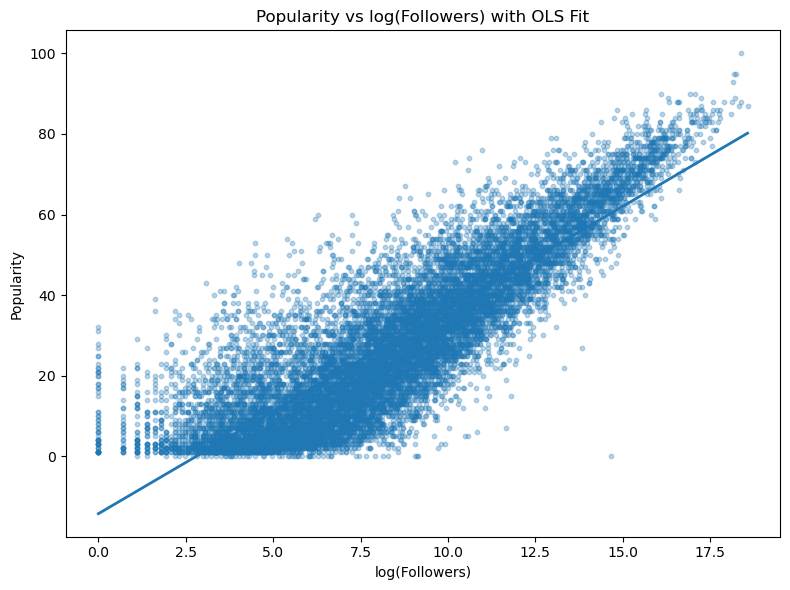


8. Over-performers (high popularity, low followers) — top 10:


,name,artist_popularity,followers,residual
0,yolibetx,32,1,46.233923
1,Yui Crystal,31,1,45.233923
2,drogi asfaltowe,39,5,45.050300
3,Solfeggio Healing Home,53,88,44.467691
4,La Melodia,28,1,42.233923
5,Jennifer Toledo,36,5,42.050300
6,EXOA,48,56,41.765932
7,Kim Akvileja,43,22,41.516680
8,Janessa Coleman,50,89,41.410235
9,Boyd Kulas,27,1,41.233923



9. Legacy artists (low popularity, high followers) — top 10:


,name,artist_popularity,followers,residual
0,Various Artists,0,2316620,-60.286546
1,A-Lex,7,117126,-38.110466
2,Corey Layne,6,50416,-34.824301
3,BTS Island: In the SEOM,22,601875,-31.433217
4,Bart Baker,15,132962,-30.755282
5,Travis Sayles,12,63591,-30.004799
6,EXO-M,27,1022518,-29.128012
7,The Dream Team,15,71194,-27.579055
8,AB,19,115433,-26.036432
9,Zonnique,17,66456,-25.228875


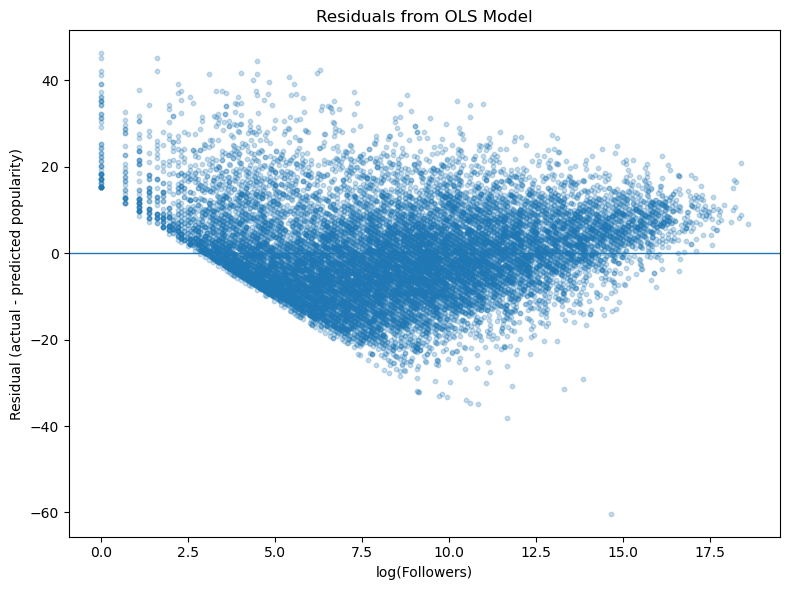

In [50]:

# 3) Popularity vs Followers: correlation + regression

corr = df["artist_popularity"].corr(df["followers"])
print(f"\n6. Pearson correlation(popularity, followers) = {corr:.4f}")

# Regression: popularity = β0 + β1 * log(followers) + ε
df["log_followers"] = np.log(df["followers"].replace(0, np.nan))
reg_df = df.dropna(subset=["log_followers", "artist_popularity"]).copy()

# Build X with constant
X = np.column_stack((np.ones(len(reg_df)), reg_df["log_followers"].values))
y = reg_df["artist_popularity"].values

# OLS estimates (normal equation)
beta = np.linalg.inv(X.T @ X) @ X.T @ y
beta_0, beta_1 = beta[0], beta[1]

print("\n7. OLS regression (no statsmodels):")
print(f"Popularity = {beta_0:.3f} + {beta_1:.3f} * log(Followers)")

# Predictions and residuals
reg_df["pred_popularity"] = beta_0 + beta_1 * reg_df["log_followers"]
reg_df["residual"] = reg_df["artist_popularity"] - reg_df["pred_popularity"]

# Plot: scatter + fitted line
plt.figure(figsize=(8, 6))
plt.scatter(reg_df["log_followers"], reg_df["artist_popularity"], s=10, alpha=0.3)

x_vals = np.linspace(reg_df["log_followers"].min(), reg_df["log_followers"].max(), 200)
y_vals = beta_0 + beta_1 * x_vals
plt.plot(x_vals, y_vals, linewidth=2)

plt.xlabel("log(Followers)")
plt.ylabel("Popularity")
plt.title("Popularity vs log(Followers) with OLS Fit")
plt.tight_layout()
plt.show()

# Over-performers and legacy artists using residuals + follower quantiles
low_follow_thresh = reg_df["followers"].quantile(0.25)
high_follow_thresh = reg_df["followers"].quantile(0.75)

over_performers = (
    reg_df[reg_df["followers"] <= low_follow_thresh]
    .sort_values("residual", ascending=False)
    .head(10)[["name", "artist_popularity", "followers", "residual"]]
    .reset_index(drop=True)
)

legacy_artists = (
    reg_df[reg_df["followers"] >= high_follow_thresh]
    .sort_values("residual", ascending=True)
    .head(10)[["name", "artist_popularity", "followers", "residual"]]
    .reset_index(drop=True)
)

print("\n8. Over-performers (high popularity, low followers) — top 10:")
display(over_performers)

print("\n9. Legacy artists (low popularity, high followers) — top 10:")
display(legacy_artists)

# Plot residuals
plt.figure(figsize=(8, 6))
plt.scatter(reg_df["log_followers"], reg_df["residual"], s=10, alpha=0.25)
plt.axhline(0, linewidth=1)
plt.xlabel("log(Followers)")
plt.ylabel("Residual (actual - predicted popularity)")
plt.title("Residuals from OLS Model")
plt.tight_layout()
plt.show()


In [57]:

# 4) Genre analysis: function to return top 10 artists in a genre

from collections import Counter

# Find genre columns
genre_cols = [c for c in df.columns if c.startswith("genre_")]

# Keep only genre columns that are NOT entirely NA (this removes genre_5 and genre_6 automatically)
genre_cols = [c for c in genre_cols if not df[c].isna().all()]

print("Genre columns used:", genre_cols)

# Create a list of genres per artist from the remaining genre columns
df["genres_list"] = df[genre_cols].apply(lambda row: [g for g in row.dropna().tolist()], axis=1)

# ---- List all unique genres ----
all_genres = [g for sublist in df["genres_list"] for g in sublist]
unique_genres = sorted(set(all_genres))

# ---- Frequency table of genres ----
genre_counts = Counter(all_genres)

genre_freq = (
    pd.DataFrame(genre_counts.items(), columns=["genre", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)

print("\nTop 15 most common genres:")
display(genre_freq.head(15))

# Function: top 10 artists in a given genre
def top10_by_genre(df_in, genre):
    g = genre.strip().lower()
    mask = df_in["genres_list"].apply(lambda lst: any(str(x).lower() == g for x in lst))
    return (
        df_in.loc[mask, ["name", "artist_popularity", "followers"]]
        .sort_values(["artist_popularity", "followers"], ascending=[False, False])
        .head(10)
        .reset_index(drop=True)
    )

# Example usage
example_genre = "pop"
print(f"\nTop 10 artists in genre '{example_genre}':")
display(top10_by_genre(df, example_genre))




Genre columns used: ['genre_0', 'genre_1', 'genre_2', 'genre_3', 'genre_4']

Top 15 most common genres:


,genre,count
0,pop,150
1,rap,125
2,dance pop,102
3,hip hop,101
4,trap,95
5,pop rap,93
6,r&b,87
7,edm,79
8,k-pop,79
9,classic rock,74



Top 10 artists in genre 'pop':


,name,artist_popularity,followers
0,Taylor Swift,100,95859165
1,The Weeknd,93,75945958
2,Lana Del Rey,89,30603103
3,Ariana Grande,88,95710972
4,Justin Bieber,88,75112165
5,Rihanna,88,59152035
6,SZA,88,16347096
7,Ed Sheeran,87,115998928
8,Billie Eilish,87,89996504
9,Olivia Rodrigo,87,30827885



11. Summary stats: number of genres per artist
count    15529.000000
mean         1.019383
std          1.359303
min          0.000000
25%          0.000000
50%          1.000000
75%          2.000000
max          5.000000
Name: n_genres, dtype: float64

12. Correlations with number of genres:
  corr(n_genres, popularity)    = 0.6471
  corr(n_genres, followers)     = 0.2401
  corr(n_genres, log_followers) = 0.7090


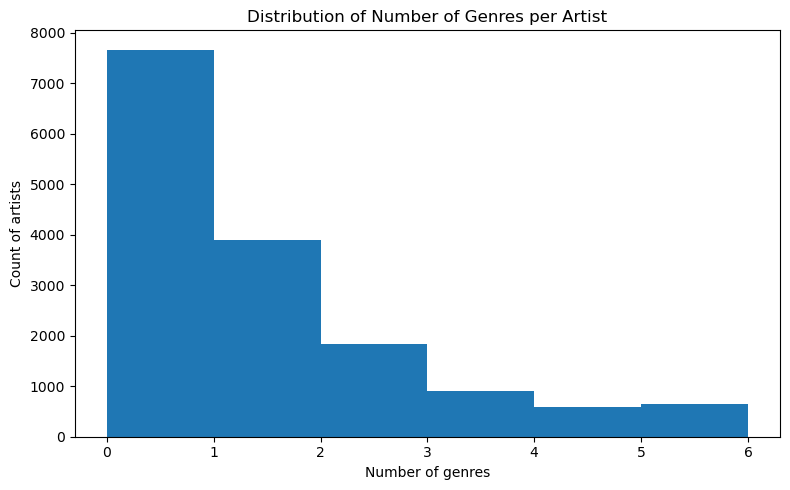

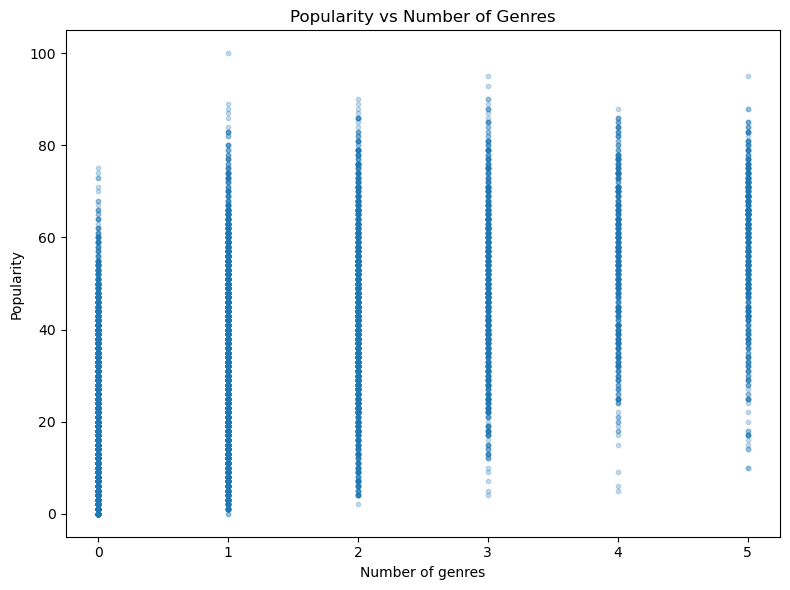

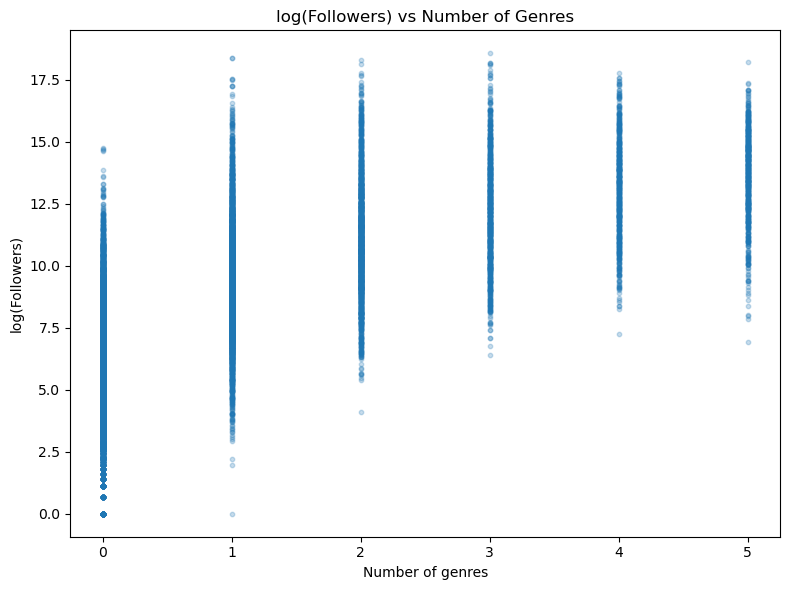

In [68]:
# 5) Number of genres per artist

df["n_genres"] = df["genres_list"].apply(len)

print("\n11. Summary stats: number of genres per artist")
print(df["n_genres"].describe())

corr_n_pop = df["n_genres"].corr(df["artist_popularity"])
corr_n_foll = df["n_genres"].corr(df["followers"])
corr_n_logf = df["n_genres"].corr(df["log_followers"])

print(f"\n12. Correlations with number of genres:")
print(f"  corr(n_genres, popularity)    = {corr_n_pop:.4f}")
print(f"  corr(n_genres, followers)     = {corr_n_foll:.4f}")
print(f"  corr(n_genres, log_followers) = {corr_n_logf:.4f}")

# Histogram of number of genres
plt.figure(figsize=(8, 5))
plt.hist(df["n_genres"], bins=range(0, int(df["n_genres"].max()) + 2))
plt.xlabel("Number of genres")
plt.ylabel("Count of artists")
plt.title("Distribution of Number of Genres per Artist")
plt.tight_layout()
plt.show()

# Scatter: popularity vs n_genres
plt.figure(figsize=(8, 6))
plt.scatter(df["n_genres"], df["artist_popularity"], s=10, alpha=0.25)
plt.xlabel("Number of genres")
plt.ylabel("Popularity")
plt.title("Popularity vs Number of Genres")
plt.tight_layout()
plt.show()

# Scatter: log_followers vs n_genres
tmp = df.dropna(subset=["log_followers"]).copy()
plt.figure(figsize=(8, 6))
plt.scatter(tmp["n_genres"], tmp["log_followers"], s=10, alpha=0.25)
plt.xlabel("Number of genres")
plt.ylabel("log(Followers)")
plt.title("log(Followers) vs Number of Genres")
plt.tight_layout()
plt.show()



